# Sampling in Python

Sampling in Python is the cornerstone of inference statistics and hypothesis testing. It's a powerful skill used in survey analysis and experimental design to draw conclusions without surveying an entire population. In this Sampling in Python course, you’ll discover when to use sampling and how to perform common types of sampling—from simple random sampling to more complex methods like stratified and cluster sampling. Using real-world datasets, including coffee ratings, Spotify songs, and employee attrition, you’ll learn to estimate population statistics and quantify uncertainty in your estimates by generating sampling distributions and bootstrap distributions.

In [1]:
import pandas as pd

In [2]:
attrition_pop = pd.read_feather('attrition.feather')
attrition_pop.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,21,0.0,Travel_Rarely,391,Research_Development,15,College,Life_Sciences,High,Male,...,Excellent,Very_High,0,0,6,Better,0,0,0,0
1,19,1.0,Travel_Rarely,528,Sales,22,Below_College,Marketing,Very_High,Male,...,Excellent,Very_High,0,0,2,Good,0,0,0,0
2,18,1.0,Travel_Rarely,230,Research_Development,3,Bachelor,Life_Sciences,High,Male,...,Excellent,High,0,0,2,Better,0,0,0,0
3,18,0.0,Travel_Rarely,812,Sales,10,Bachelor,Medical,Very_High,Female,...,Excellent,Low,0,0,2,Better,0,0,0,0
4,18,1.0,Travel_Frequently,1306,Sales,5,Bachelor,Marketing,Medium,Male,...,Excellent,Very_High,0,0,3,Better,0,0,0,0


In [4]:
coffee_ratings = pd.read_feather('coffee_ratings_full.feather')
coffee_ratings.head()

,total_cup_points,species,owner,country_of_origin,farm_name,lot_number,mill,ico_number,company,altitude,...,color,category_two_defects,expiration,certification_body,certification_address,certification_contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,90.58,Arabica,metad plc,Ethiopia,metad plc,None,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,89.92,Arabica,metad plc,Ethiopia,metad plc,None,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,89.75,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",None,None,None,None,1600 - 1800 m,...,None,0.0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,89.00,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,None,wolensu,None,yidnekachew debessa coffee plantation,1800-2200,...,Green,2.0,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,88.83,Arabica,metad plc,Ethiopia,metad plc,None,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2.0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


In [5]:
coffee_ratings.shape

(1338, 43)

In [6]:
pts_vs_flavor = coffee_ratings[['total_cup_points', 'flavor']]
pts_vs_flavor.head()

,total_cup_points,flavor
0,90.58,8.83
1,89.92,8.67
2,89.75,8.50
3,89.00,8.58
4,88.83,8.50


In [7]:
# get 10 random samples
pts_vs_flavor_samp = pts_vs_flavor.sample(n=10)

In [8]:
pts_vs_flavor.mean()

total_cup_points    82.151203
flavor               7.526046
dtype: float64

In [9]:
pts_vs_flavor_samp.mean()

total_cup_points    83.285
flavor               7.608
dtype: float64

In [12]:
# can use .sample on a column
cup_points_samp = coffee_ratings['total_cup_points'].sample(n=10)
cup_points_samp

287     83.83
144     84.58
1337    73.75
1153    79.75
878     81.67
959     81.33
965     81.25
59      85.75
630     82.67
734     82.25
Name: total_cup_points, dtype: float64

In [14]:
import numpy as np
np.mean(pts_vs_flavor['total_cup_points'])

np.float64(82.15120328849028)

In [15]:
np.mean(cup_points_samp)

np.float64(81.68299999999999)

In [16]:
# use pandas for the mean (rather than numpy)
pts_vs_flavor['flavor'].mean()

np.float64(7.526046337817639)

In [17]:
pts_vs_flavor_samp['flavor'].mean()

np.float64(7.608)

In [18]:
# read in Spotify data set
spotify_population = pd.read_feather('spotify_2000_2020.feather')
spotify_population.head()

,acousticness,artists,danceability,duration_ms,duration_minutes,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,valence,year
0,0.97200,['David Bauer'],0.567,313293.0,5.221550,0.227,0.0,0w0D8H1ubRerCXHWYJkinO,0.601000,10.0,0.110,-13.441,1.0,Shout to the Lord,47.0,2000,0.0290,136.123,0.0396,2000.0
1,0.32100,['Etta James'],0.821,360240.0,6.004000,0.418,0.0,4JVeqfE2tpi7Pv63LJZtPh,0.000372,9.0,0.222,-9.841,0.0,Miss You,51.0,2000-12-12,0.0407,117.382,0.8030,2000.0
2,0.00659,['Quasimoto'],0.706,202507.0,3.375117,0.602,1.0,5pxtdhLAi0RTh1gNqhGMNA,0.000138,11.0,0.400,-8.306,0.0,Real Eyes,44.0,2000-06-13,0.3420,89.692,0.4790,2000.0
3,0.00390,['Millencolin'],0.368,173360.0,2.889333,0.977,0.0,3jRsoe4Vkxa4BMYqGHX8L0,0.000000,11.0,0.350,-2.757,0.0,Penguins & Polarbears,52.0,2000-02-22,0.1270,165.889,0.5480,2000.0
4,0.12200,['Steve Chou'],0.501,344200.0,5.736667,0.511,0.0,4mronxcllhfyhBRqyZi8kU,0.000000,7.0,0.279,-9.836,0.0,黃昏,53.0,2000-12-25,0.0291,78.045,0.1130,2000.0


In [19]:
# Sample 1000 rows from spotify_population
spotify_sample = spotify_population.sample(n=1000)
spotify_sample.head()

,acousticness,artists,danceability,duration_ms,duration_minutes,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,valence,year
10924,0.28100,['Toño Rosario'],0.850,285800.0,4.763333,0.733,0.0,2RZFwxo5JrPl8xiVHIKlhs,0.000000,5.0,0.3380,-5.321,0.0,El Reloj,38.0,2004-01-01,0.0490,115.983,0.787,2004.0
22987,0.14100,['The Beatles'],0.650,136827.0,2.280450,0.777,0.0,1raiIrqaqRAqZmQWZlLuBd,0.343000,2.0,0.2150,-4.984,1.0,Lady Madonna - Remastered 2015,62.0,2000-11-13,0.0294,109.608,0.574,2000.0
35360,0.00525,['Joyner Lucas'],0.563,205872.0,3.431200,0.780,1.0,4X4v3KtkUXwXvDBw5KS9cp,0.000008,10.0,0.4180,-6.663,1.0,ADHD,71.0,2020-03-27,0.0782,83.913,0.317,2020.0
13242,0.00434,['Gary Moore'],0.479,255720.0,4.262000,0.822,0.0,1o0hcMxI6jYzQm6ApPde3L,0.000005,4.0,0.0843,-6.412,0.0,Wild Frontier - Remastered 2002,48.0,2006,0.0444,130.035,0.562,2006.0
26361,0.02920,['Grouplove'],0.492,196027.0,3.267117,0.779,0.0,1F5A4LpF8ylUVtPoMAvNvn,0.000000,3.0,0.1290,-5.022,1.0,Raspberry,62.0,2013-09-17,0.0498,104.966,0.445,2013.0


In [20]:
# Calculate the mean duration in mins from spotify_population
mean_dur_pop = spotify_population['duration_minutes'].mean()

# Calculate the mean duration in mins from spotify_sample
mean_dur_samp = spotify_sample['duration_minutes'].mean()

# Print the means
print(mean_dur_pop)
print(mean_dur_samp)


3.8521519140900073
3.8770333499999996


In [21]:
# Create a pandas Series from the loudness column of spotify_population
loudness_pop = spotify_population['loudness']

# Sample 100 values of loudness_pop
loudness_samp = loudness_pop.sample(n=100)

print(loudness_samp)

7445     -3.828
25136    -5.218
27473    -8.333
38742    -4.760
6382     -8.410
          ...  
18655    -3.374
28293    -6.005
19950   -10.999
18191    -6.327
24622    -5.473
Name: loudness, Length: 100, dtype: float64


In [22]:
# Calculate the mean of loudness_pop
mean_loudness_pop = np.mean(loudness_pop)

# Calculate the mean of loudness_samp
mean_loudness_samp = np.mean(loudness_samp )

print(mean_loudness_pop)
print(mean_loudness_samp)

-7.366856851353947
-7.472799999999999


## Convenience sampling

In [23]:
coffee_ratings["total_cup_points"].mean()

np.float64(82.15120328849028)

In [24]:
coffee_ratings_first10 = coffee_ratings.head(10)
coffee_ratings_first10 ["total_cup_points"].mean()

np.float64(89.1)

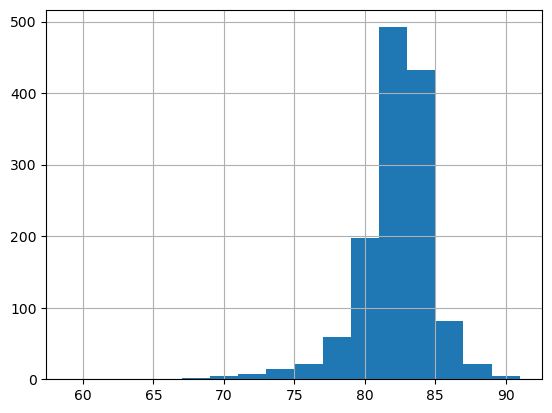

In [26]:
import matplotlib.pyplot as plt
import numpy as np
coffee_ratings["total_cup_points"].hist(bins=np.arange(59, 93, 2))
plt.show()

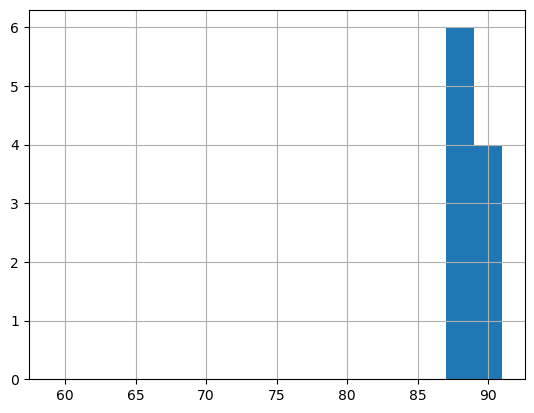

In [27]:
coffee_ratings_first10["total_cup_points"].hist(bins=np.arange(59, 93, 2))
plt.show()

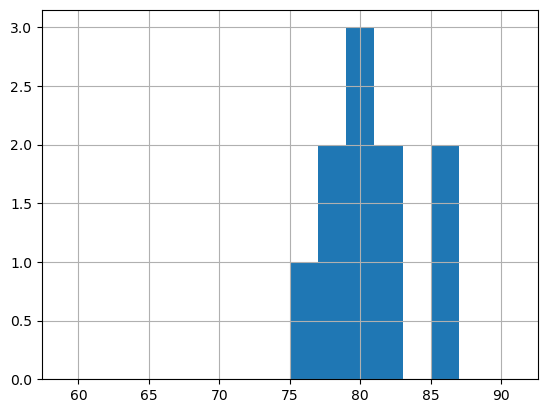

In [28]:
# rather than using the first 10 we will take a random sample
coffee_sample = coffee_ratings.sample(n=10)
coffee_sample["total_cup_points"].hist(bins=np.arange(59,93, 2))
plt.show()

### Are findings from the sample generalizable?

You just saw how convenience sampling—collecting data using the easiest method—can result in samples that aren't representative of the population. Equivalently, this means findings from the sample are not generalizable to the population. Visualizing the distributions of the population and the sample can help determine whether or not the sample is representative of the population.
The Spotify dataset contains an acousticness column, which is a confidence measure from zero to one of whether the track was made with instruments that aren't plugged in. You'll compare the acousticness distribution of the total population of songs with a sample of those songs.


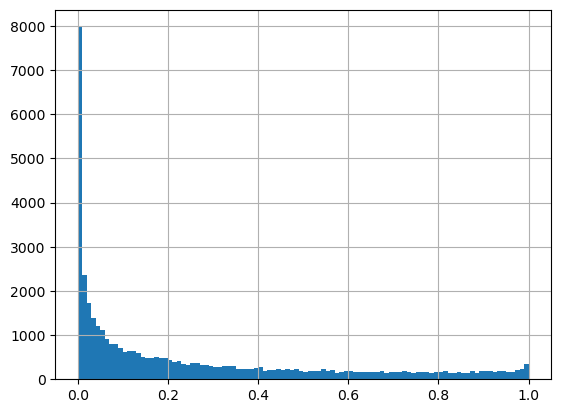

In [29]:
# Plot a histogram of the acousticness from spotify_population with bins of width 0.01 from 0 to 1 using pandas .hist()
spotify_population['acousticness'].hist(bins=np.arange(0, 1.01, 0.01))
plt.show()